In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 读取数据
a = pd.read_csv(r"C:\Users\111\Desktop\qihui_obs_update.csv")
print(a.columns)  # 打印列名以确认数据结构

print(a.head())  # 打印前几行数据以检查内容


正在进行数据验证...


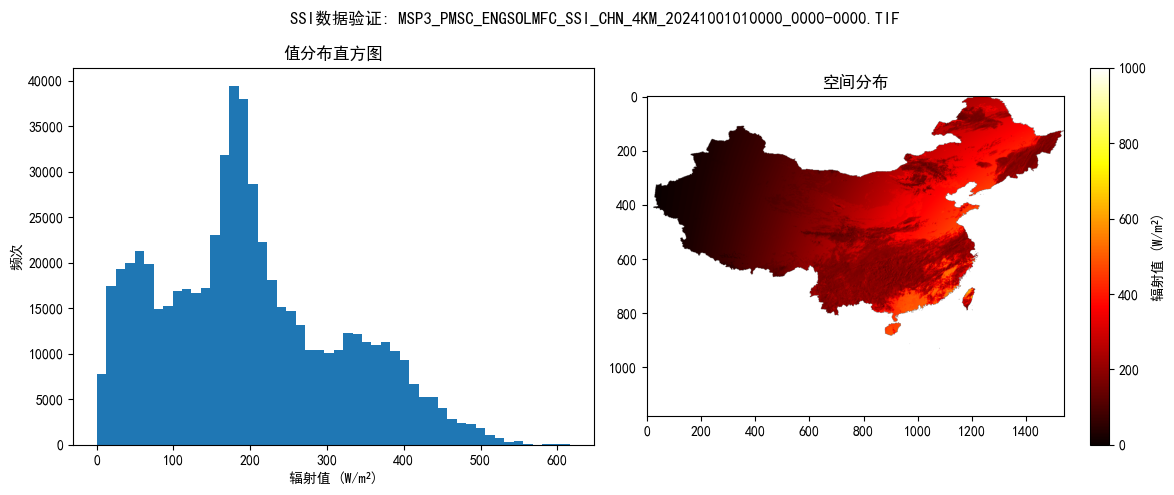


验证结果 - MSP3_PMSC_ENGSOLMFC_SSI_CHN_4KM_20241001010000_0000-0000.TIF:
  最小值: 0.01 W/m²
  最大值: 617.06 W/m²
  均值: 199.31 W/m²
  无效值数量: 0


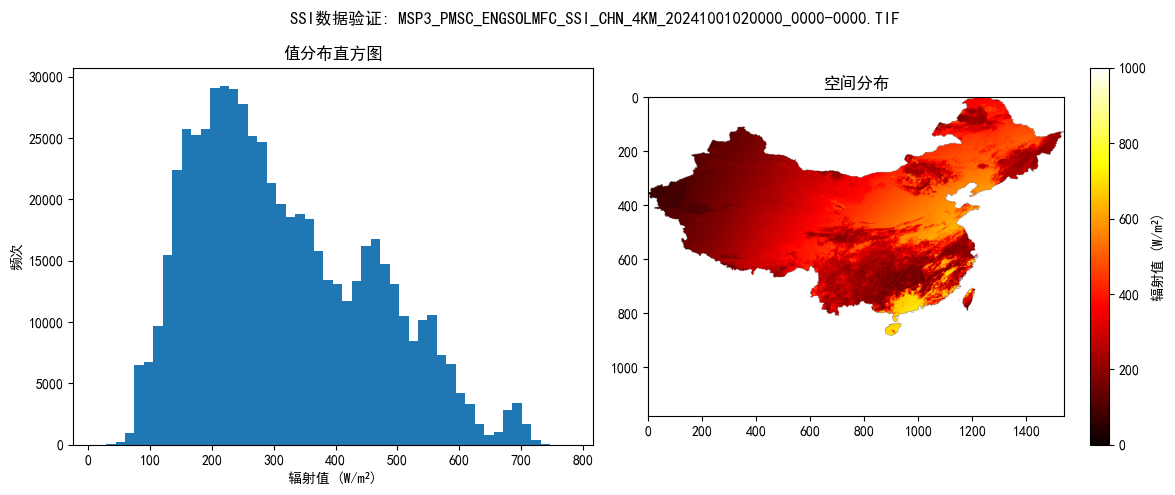


验证结果 - MSP3_PMSC_ENGSOLMFC_SSI_CHN_4KM_20241001020000_0000-0000.TIF:
  最小值: 14.09 W/m²
  最大值: 777.44 W/m²
  均值: 315.72 W/m²
  无效值数量: 0


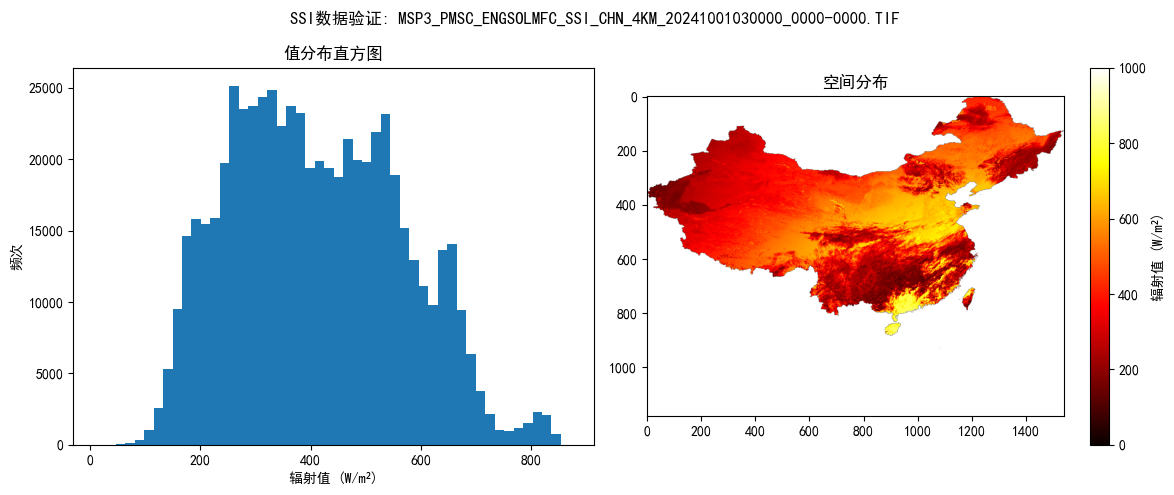


验证结果 - MSP3_PMSC_ENGSOLMFC_SSI_CHN_4KM_20241001030000_0000-0000.TIF:
  最小值: 11.77 W/m²
  最大值: 872.00 W/m²
  均值: 411.61 W/m²
  无效值数量: 0

开始提取站点数据...


处理进度: 100%|██████████| 746/746 [00:07<00:00, 95.66it/s]
C:\Users\111\AppData\Local\Temp\ipykernel_18784\4098356012.py:137: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  obs_df['Datetime'] = obs_df['Datetime'].dt.to_pydatetime()



有效数据点数: 626/746
地面观测数据点数: 2890

对比图已保存至: C:\Users\111\Desktop\武博卫星反演数据评估\FY4B_SSR_corrected\output_plots\启辉_辐射对比.png


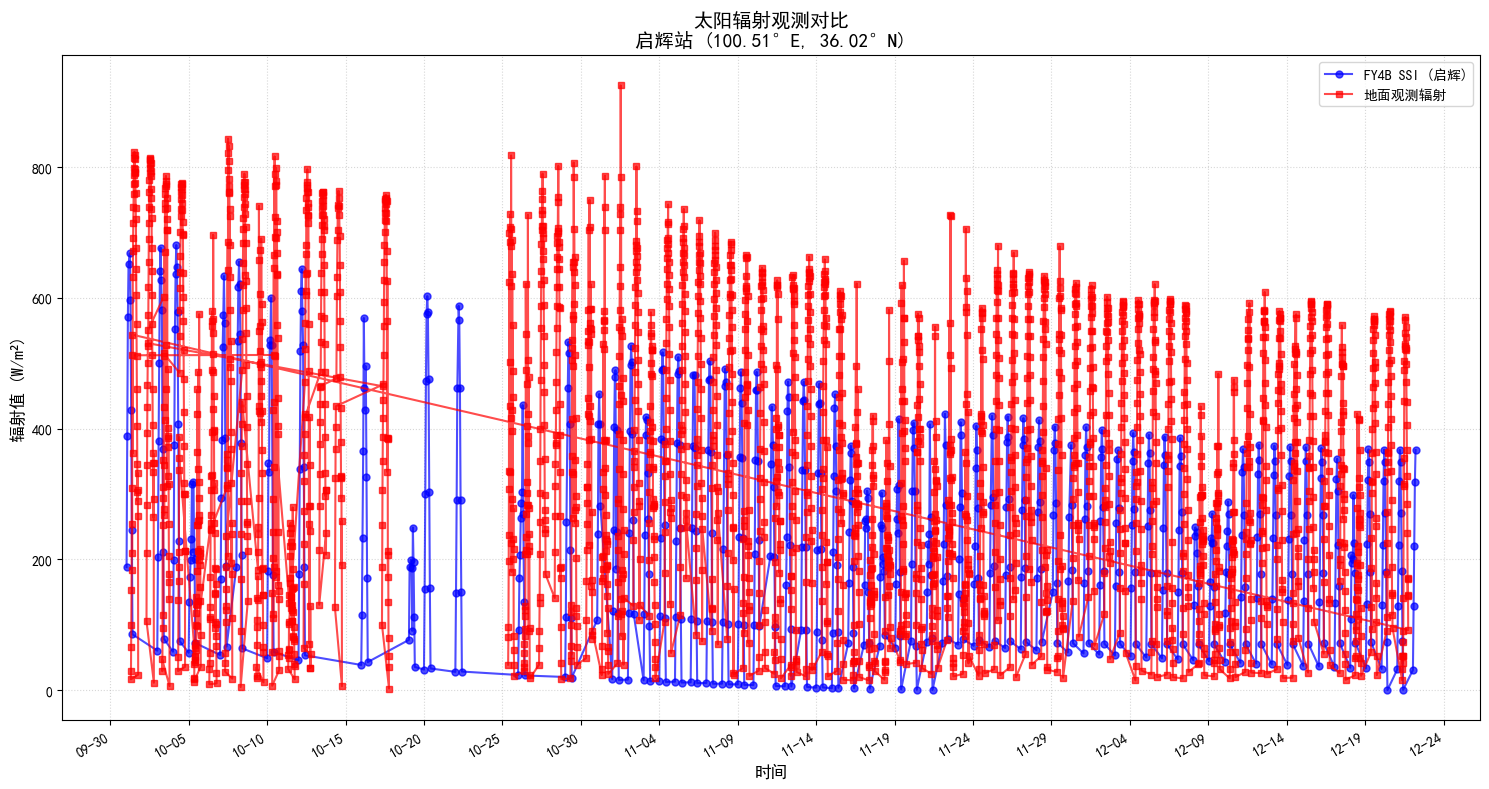

卫星数据图已保存至: C:\Users\111\Desktop\武博卫星反演数据评估\FY4B_SSR_corrected\output_plots\启辉_FY4B_SSI.png


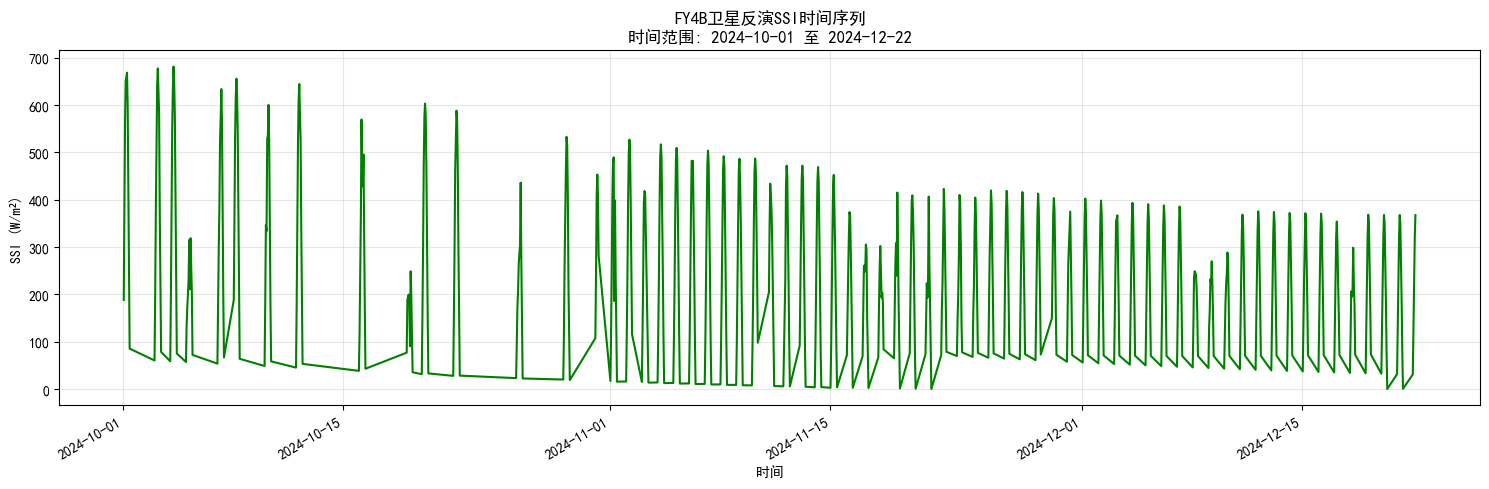

In [4]:
import os
import glob
import pandas as pd
from datetime import datetime
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from tqdm import tqdm

# 设置中文显示
plt.rcParams["font.family"] = ["SimHei", "Microsoft YaHei",]
plt.rcParams["axes.unicode_minus"] = False

# ==================== 配置参数 ====================
# 站点信息
STATION_NAME = "启辉"
STATION_LON, STATION_LAT = 100.51, 36.02  # 经纬度

# 路径配置
BASE_PATH = r"C:\Users\111\Desktop\武博卫星反演数据评估\FY4B_SSR_corrected"
CSV_PATH = r"C:\Users\111\Desktop\qihui_obs_update.csv"
OUTPUT_DIR = os.path.join(BASE_PATH, "output_plots")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# SSI验证参数
SSI_VALID_RANGE = (0, 1500)  # 合理物理范围 (W/m²)
NODATA_VALUES = [-9999, 65535, np.nan]  # 无效值标记

# ==================== 函数定义 ====================
def validate_ssi_data(tif_file):
    """验证TIFF文件是否包含有效SSI数据"""
    with rasterio.open(tif_file) as src:
        data = src.read(1)
        
        # 统计信息
        stats = {
            'min': np.nanmin(data),
            'max': np.nanmax(data),
            'mean': np.nanmean(data),
            'nodata': np.sum(np.isin(data, NODATA_VALUES))
        }
        
        # 可视化验证
        plt.figure(figsize=(12, 5))
        plt.subplot(121)
        plt.hist(data[~np.isin(data, NODATA_VALUES)].flatten(), bins=50)
        plt.xlabel('辐射值 (W/m²)')
        plt.ylabel('频次')
        plt.title('值分布直方图')
        
        plt.subplot(122)
        plt.imshow(data, vmin=0, vmax=1000, cmap='hot')
        plt.colorbar(label='辐射值 (W/m²)')
        plt.title('空间分布')
        
        plt.suptitle(f"SSI数据验证: {os.path.basename(tif_file)}")
        plt.tight_layout()
        plt.show()
        
        return stats

def safe_extract_ssi(tif_file, lon, lat):
    """安全提取SSI值，包含严格验证"""
    try:
        with rasterio.open(tif_file) as src:
            data = src.read(1)
            row, col = src.index(lon, lat)
            
            # 边界检查
            if not (0 <= row < data.shape[0] and 0 <= col < data.shape[1]):
                return None
                
            value = data[row, col]
            
            # 有效性验证
            if (value in NODATA_VALUES) or (not SSI_VALID_RANGE[0] <= value <= SSI_VALID_RANGE[1]):
                return None
                
            return float(value)
    except Exception as e:
        print(f"处理失败 {os.path.basename(tif_file)}: {str(e)}")
        return None

def parse_time(filename):
    """从文件名解析时间 (格式: MSP3_..._20241001000000_0000-0000.TIF)"""
    try:
        datetime_str = filename.split('_')[-2][:10]  # 提取前10位 (YYYYMMDDHH)
        return datetime.strptime(datetime_str, "%Y%m%d%H")
    except:
        return None

# ==================== 主流程 ====================
if __name__ == "__main__":
    # 1. 数据验证阶段
    print("正在进行数据验证...")
    sample_files = glob.glob(os.path.join(BASE_PATH, "**", "MSP3_PMSC_ENGSOLMFC_SSI_CHN_4KM_*.TIF"), recursive=True)[:3]
    for file in sample_files:
        stats = validate_ssi_data(file)
        print(f"\n验证结果 - {os.path.basename(file)}:")
        print(f"  最小值: {stats['min']:.2f} W/m²")
        print(f"  最大值: {stats['max']:.2f} W/m²")
        print(f"  均值: {stats['mean']:.2f} W/m²")
        print(f"  无效值数量: {stats['nodata']}")

    # 2. 批量处理TIFF文件
    print("\n开始提取站点数据...")
    tif_files = glob.glob(os.path.join(BASE_PATH, "**", "MSP3_PMSC_ENGSOLMFC_SSI_CHN_4KM_*.TIF"), recursive=True)
    ssi_data = []
    
    for tif_file in tqdm(tif_files, desc="处理进度"):
        time_obj = parse_time(os.path.basename(tif_file))
        if not time_obj:
            continue
            
        ssi = safe_extract_ssi(tif_file, STATION_LON, STATION_LAT)
        if ssi is not None:
            ssi_data.append({'time': time_obj, 'ssi': ssi})

    # 转换为DataFrame
    ssi_df = pd.DataFrame(ssi_data).sort_values('time').drop_duplicates('time')
    print(f"\n有效数据点数: {len(ssi_df)}/{len(tif_files)}")

    # 3. 处理地面观测数据 (CSV) - 修复日期解析问题
    try:
        # 关键修复：使用format='mixed'让pandas自动识别多种日期格式
        # 或者根据实际格式指定，例如：format='%Y/%m/%d %H:%M'
        obs_df = pd.read_csv(
            CSV_PATH,
            parse_dates=['Datetime'],
            date_format='mixed'  # 处理混合格式的日期字符串
        )
        
        # 确保日期格式正确
        obs_df['Datetime'] = pd.to_datetime(obs_df['Datetime'], errors='coerce')
        obs_df = obs_df.dropna(subset=['Datetime'])  # 删除解析失败的行
        obs_df['Datetime'] = obs_df['Datetime'].dt.to_pydatetime()
        
        # 过滤无效观测值
        obs_df = obs_df[obs_df['radi'] > 0]
        
        # 截取相同时间范围
        if not ssi_df.empty:
            obs_df = obs_df[
                (obs_df['Datetime'] >= ssi_df['time'].min()) & 
                (obs_df['Datetime'] <= ssi_df['time'].max())
            ]
        
        print(f"地面观测数据点数: {len(obs_df)}")
    except Exception as e:
        print(f"CSV处理失败: {str(e)}")
        obs_df = pd.DataFrame()

    # 4. 绘图功能
    plt.figure(figsize=(15, 8))
    
    # 绘制卫星数据
    plt.plot(ssi_df['time'], ssi_df['ssi'], 
             'b-', marker='o', markersize=5, 
             label=f'FY4B SSI ({STATION_NAME})', alpha=0.7)
    
    # 绘制地面观测数据 (如果存在)
    if not obs_df.empty:
        plt.plot(obs_df['Datetime'], obs_df['radi'], 
                 'r-', marker='s', markersize=4, 
                 label='地面观测辐射', alpha=0.7)
    
    # 图形美化
    plt.title(f'太阳辐射观测对比\n{STATION_NAME}站 ({STATION_LON}°E, {STATION_LAT}°N)', fontsize=14)
    plt.xlabel('时间', fontsize=12)
    plt.ylabel('辐射值 (W/m²)', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.5)
    
    # 时间轴设置
    ax = plt.gca()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
    plt.gcf().autofmt_xdate()
    
    plt.legend(fontsize=10)
    plt.tight_layout()
    
    # 保存图片
    output_path = os.path.join(OUTPUT_DIR, f"{STATION_NAME}_辐射对比.png")
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"\n对比图已保存至: {output_path}")
    plt.show()

    # 5. 单独绘制卫星数据
    plt.figure(figsize=(15, 5))
    plt.plot(ssi_df['time'], ssi_df['ssi'], 'g-', label='FY4B SSI')
    plt.title(f'FY4B卫星反演SSI时间序列\n时间范围: {ssi_df["time"].min().date() if not ssi_df.empty else "无数据"} 至 {ssi_df["time"].max().date() if not ssi_df.empty else "无数据"}')
    plt.xlabel('时间')
    plt.ylabel('SSI (W/m²)')
    plt.grid(True, alpha=0.3)
    plt.gcf().autofmt_xdate()
    plt.tight_layout()
    
    output_path = os.path.join(OUTPUT_DIR, f"{STATION_NAME}_FY4B_SSI.png")
    plt.savefig(output_path, dpi=300)
    print(f"卫星数据图已保存至: {output_path}")
    plt.show()

    # 6. 保存数据结果
    ssi_df.to_csv(os.path.join(OUTPUT_DIR, "extracted_ssi.csv"), index=False)
    if not obs_df.empty:
        obs_df.to_csv(os.path.join(OUTPUT_DIR, "extracted_obs.csv"), index=False)

文件基本信息:
文件路径: C:\Users\111\Desktop\武博卫星反演数据评估\FY4B_SSR_corrected\202410\20241001\20241001010000\MSP3_PMSC_ENGSOLMFC_SSI_CHN_4KM_20241001010000_0000-0000.TIF
驱动: GTiff
波段数量: 1
图像宽度: 1540
图像高度: 1181
数据类型: float32

地理参考信息:
坐标参考系统(CRS): EPSG:4326
变换矩阵(transform): | 0.04, 0.00, 73.50|
| 0.00,-0.04, 53.56|
| 0.00, 0.00, 1.00|
边界范围(bounds): BoundingBox(left=73.5009857599408, bottom=6.320261104868202, right=135.1009857599408, top=53.560261104868204)

数据统计信息:
最小值: 0.013501317240297794
最大值: 617.0640869140625
平均值: 199.30787658691406
中位数: 185.81253051757812
标准差: 118.25670623779297

无效值检查:
无效值(NODATA): nan
无效值数量: 0

生成预览图...


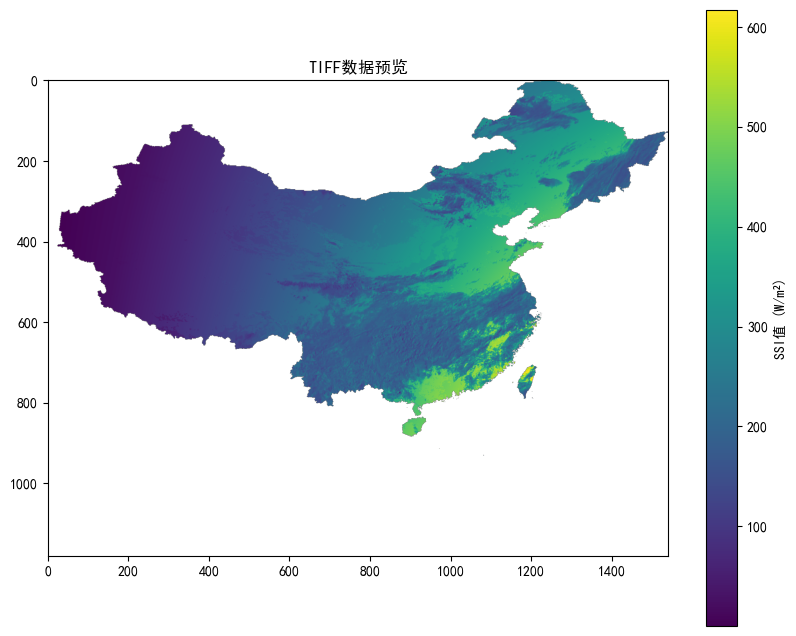


完整元数据:
{'AREA_OR_POINT': 'Area'}
波段元数据:
{}


In [7]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# 指定TIFF文件路径
tif_path =r"C:\Users\111\Desktop\武博卫星反演数据评估\FY4B_SSR_corrected\202410\20241001\20241001010000\MSP3_PMSC_ENGSOLMFC_SSI_CHN_4KM_20241001010000_0000-0000.TIF"

# 打开TIFF文件并读取元数据
with rasterio.open(tif_path) as src:
    # 1. 基本信息
    print("="*50)
    print("文件基本信息:")
    print(f"文件路径: {tif_path}")
    print(f"驱动: {src.driver}")
    print(f"波段数量: {src.count}")
    print(f"图像宽度: {src.width}")
    print(f"图像高度: {src.height}")
    print(f"数据类型: {src.dtypes[0]}")
    
    # 2. 地理参考信息（如果是GeoTIFF）
    print("\n" + "="*50)
    print("地理参考信息:")
    print(f"坐标参考系统(CRS): {src.crs}")
    print(f"变换矩阵(transform): {src.transform}")
    print(f"边界范围(bounds): {src.bounds}")
    
    # 3. 数据统计信息
    print("\n" + "="*50)
    print("数据统计信息:")
    data = src.read(1)  # 读取第一个波段
    print(f"最小值: {np.nanmin(data)}")
    print(f"最大值: {np.nanmax(data)}")
    print(f"平均值: {np.nanmean(data)}")
    print(f"中位数: {np.nanmedian(data)}")
    print(f"标准差: {np.nanstd(data)}")
    
    # 4. 检查无效值
    print("\n" + "="*50)
    print("无效值检查:")
    print(f"无效值(NODATA): {src.nodatavals[0]}")
    print(f"无效值数量: {np.sum(data == src.nodatavals[0])}")
    
    # 5. 可视化
    print("\n" + "="*50)
    print("生成预览图...")
    plt.figure(figsize=(10, 8))
    plt.imshow(data, cmap='viridis')
    plt.colorbar(label='SSI值 (W/m²)')
    plt.title("TIFF数据预览")
    plt.show()

    # 6. 元数据（所有标签）
    print("\n" + "="*50)
    print("完整元数据:")
    print(src.tags())
    print("波段元数据:")
    print(src.tags(1))  # 第一个波段的元数据

In [8]:
import pandas as pd
import numpy as np

def analyze_radi_data(csv_path):
    """
    读取CSV文件并计算radi列的统计信息
    
    参数:
        csv_path: CSV文件路径
    返回:
        包含统计信息的字典（若失败则返回None）
    """
    try:
        # 读取CSV文件，自动解析日期列（若有）
        # 假设日期列名为'Datetime'，可根据实际情况修改
        df = pd.read_csv(
            csv_path,
            parse_dates=['Datetime'],  # 解析日期列（若存在）
            date_format='mixed',       # 处理多种日期格式
            na_values=['', ' ', 'NaN'] # 识别无效值
        )
        
        # 检查是否包含'radi'列
        if 'radi' not in df.columns:
            print(f"错误：CSV文件中未找到'radi'列，请检查列名是否正确。")
            return None
        
        # 提取radi列并过滤无效值（如负数、NaN）
        radi_data = df['radi'].dropna()  # 删除空值
        radi_data = radi_data[radi_data >= 0]  # 辐射值不能为负（根据物理意义过滤）
        
        if len(radi_data) == 0:
            print("警告：经过过滤后，'radi'列无有效数据。")
            return None
        
        # 计算统计指标
        stats = {
            '数据总量': len(df['radi']),  # 原始数据总数
            '有效数据量': len(radi_data),  # 过滤后有效数据数
            '缺失值数量': len(df['radi']) - len(radi_data.dropna()),  # 空值数量
            '最小值': round(radi_data.min(), 3),
            '最大值': round(radi_data.max(), 3),
            '平均值': round(radi_data.mean(), 3),
            '中位数': round(radi_data.median(), 3),
            '标准差': round(radi_data.std(), 3),  # 数据离散程度
            '方差': round(radi_data.var(), 3),    # 标准差的平方
            '25%分位数': round(radi_data.quantile(0.25), 3),  # 25%的数据小于该值
            '75%分位数': round(radi_data.quantile(0.75), 3)   # 75%的数据小于该值
        }
        
        # 打印统计结果
        print("===== 'radi'列统计信息 =====")
        for key, value in stats.items():
            print(f"{key}: {value}")
        
        return stats
    
    except FileNotFoundError:
        print(f"错误：文件未找到，请检查路径是否正确：{csv_path}")
        return None
    except Exception as e:
        print(f"处理CSV时发生错误：{str(e)}")
        return None

# ==================== 主程序 ====================
if __name__ == "__main__":
    # 替换为你的CSV文件路径
    csv_path = r"C:\Users\111\Desktop\qihui_obs_update.csv"
    # 调用函数计算统计信息
    analyze_radi_data(csv_path)

===== 'radi'列统计信息 =====
数据总量: 50597
有效数据量: 50594
缺失值数量: 3
最小值: 0.0
最大值: 968.0
平均值: 210.367
中位数: 0.0
标准差: 282.355
方差: 79724.484
25%分位数: 0.0
75%分位数: 416.915
